In [1]:
import sys
sys.path.append('/home/brian/Desktop/IA/STWebApp/machineLearningApp/MachineLearning')
from python_course.code.cp_examples import run

Datos cargados - Train: torch.Size([59950, 784]), Test: torch.Size([10000, 784]), Cal: torch.Size([50, 784])
🔊 Ruido aplicado con nivel 0.20
Modelo mlp creado exitosamente
🚀 Entrenando modelo base...
Epoch 1: Train Loss: 0.6317
✅ Modelo entrenado
🎯 Calibrando clasificador conformal con alpha=0.5
✅ Clasificador conformal calibrado
Accuracy del modelo: 0.9231
Casos con múltiples clases: 3


AttributeError: 'NoneType' object has no attribute 'has'

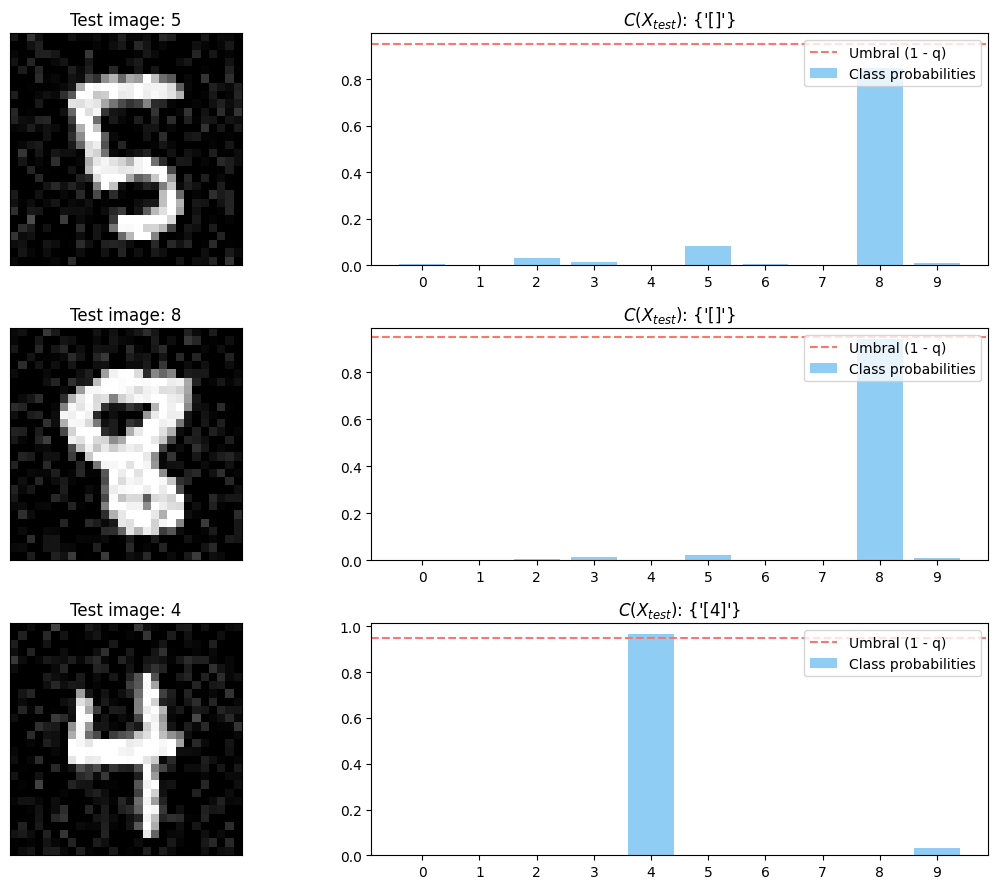

In [2]:
alpha = 0.5#0.008
noise_level = 0.2
use_cache = False

results1, figures1 = run(model_type="mlp", alpha=alpha, noise_level=noise_level)

In [3]:
import sys
sys.path.append('/home/brian/Desktop/IA/STWebApp/machineLearningApp/MachineLearning')

from python_course.code.cp_examples import ConformalPredictionDemo

demo = ConformalPredictionDemo()
demo.load_and_process_data()    # ← Método correcto
demo.create_model()             # ← Crear el modelo
demo.train_model()              # ← Entrenar
demo.calibrate(alpha_=0.5)     # ← Calibrar (no calibrate_conformal)
results = demo.evaluate_model() # ← Evaluar
print(results)

Datos cargados - Train: torch.Size([59950, 784]), Test: torch.Size([10000, 784]), Cal: torch.Size([50, 784])
Modelo mlp creado exitosamente
🚀 Entrenando modelo base...
Epoch 1: Train Loss: 0.6290
✅ Modelo entrenado
🎯 Calibrando clasificador conformal con alpha=0.5
✅ Clasificador conformal calibrado
Accuracy del modelo: 0.9292
Casos con múltiples clases: 3
PredictionResults(accuracy=0.9291999936103821, predictions=array([7, 2, 1, ..., 4, 5, 6], shape=(10000,)), prediction_sets=[array([7]), array([], dtype=int64), array([1]), array([0]), array([], dtype=int64), array([1]), array([], dtype=int64), array([], dtype=int64), array([], dtype=int64), array([], dtype=int64), array([0]), array([], dtype=int64), array([], dtype=int64), array([0]), array([1]), array([], dtype=int64), array([], dtype=int64), array([7]), array([], dtype=int64), array([4]), array([], dtype=int64), array([6]), array([], dtype=int64), array([5]), array([], dtype=int64), array([0]), array([7]), array([], dtype=int64), ar

In [4]:
# Ejecuta paso a paso en el notebook
try:
    print("1. Predicción del modelo...")
    y_pred = demo.model.predict(demo.data['X_test'])
    print("✅ model.predict() funcionó")
    
    print("2. predict_set...")
    pred_sets = demo.cp_model.predict_set(demo.data['X_test'])
    print("✅ predict_set() funcionó")
    
    print("3. predict_proba...")
    probabilidades = demo.cp_model.predict_proba(demo.data['X_test'])
    print("✅ predict_proba() funcionó")
    
except Exception as e:
    print(f"❌ Error en paso: {e}")
    import traceback
    traceback.print_exc()

1. Predicción del modelo...
✅ model.predict() funcionó
2. predict_set...
✅ predict_set() funcionó
3. predict_proba...
✅ predict_proba() funcionó


In [5]:
import numpy as np

alpha = 0.008
n_scores = 50

# Cálculo del problema
q_val = np.ceil((1 - alpha) * (n_scores + 1)) / n_scores
q_val = min(q_val, 1.0)
print(f"q_val = {q_val}")  # ¡Esto dará > 1!

# Verificación
print(f"(1 - alpha) * (n + 1) = {(1 - 0.008) * 51}")
print(f"ceil(...) / n = {np.ceil(50.592) / 50}")
print(f"ceil(50.592) = {np.ceil(50.592)}")

q_val = 1.0
(1 - alpha) * (n + 1) = 50.592
ceil(...) / n = 1.02
ceil(50.592) = 51.0
